# Problema:
## Imagina que eres un investigador médico que recopila datos para un estudio. Has recopilado datos sobre un conjunto de pacientes, todos ellos con la misma enfermedad. Durante su tratamiento, cada paciente ha respondido a uno de los 5 medicamentos, el fármaco A, el fármaco B, el fármaco c, el fármaco X y el Y. 

## Parte de tu trabajo consiste en construir un modelo para averiguar qué medicamento podría ser apropiado para un futuro paciente con la misma enfermedad. Los conjuntos de características de este conjunto de datos son la edad, el sexo, la presión arterial y el colesterol de los pacientes, y el objetivo es estudiar el fármaco al que respondió cada paciente. 

## Se trata de un ejemplo de clasificación multiclase, y se puede utilizar la parte de entrenamiento del conjunto de datos para construir un árbol de decisión, y luego utilizarlo para predecir la clase de un paciente desconocido, o para prescribirlo a un nuevo paciente.

In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot
import warnings
import numpy as np

warnings.filterwarnings("ignore")

#Todo lo mantengo en la misma carpeta, pero este codigo se utilizaria para cambiar la ubicación del directorio utilizado
# import os
# os.getcwd()
# os.chdir('C:\\Users\\saulim\\Documents\\Python Proyectos\\Jupyter notebook\\Aprendizaje de máquina supervisado\\M23- Arboles de decision')

In [3]:
BD_drugs = pd.read_csv("drugs.csv")
BD_drugs.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


## Cargue la base de datos “drugs.csv” en Python e investigue cómo convertir las variables predictoras cualitativas de esta base a una escala numérica mediante la instrucción “preprocessing.LabelEncoder()”.
## Por ejemplo, si una variable tiene 3 posibles categorías, deberá cambiar sus resultados a 0, 1 o 2. 

In [7]:
feature_cols = ["Age","Sex", "BP", "Cholesterol", "Na_to_K"]

X = BD_drugs[feature_cols].values
y = BD_drugs.Drug

In [9]:
from sklearn import preprocessing

Cod_Sex = preprocessing.LabelEncoder()
Cod_BP = preprocessing.LabelEncoder()
Cod_Cholesterol = preprocessing.LabelEncoder()

Cod_Sex.fit(list(set(X[:,1])))
Cod_BP.fit(list(set(X[:,2])))
Cod_Cholesterol.fit(list(set(X[:,3])))

X[:,1] = Cod_Sex.transform(X[:,1])
X[:,2] = Cod_BP.transform(X[:,2])
X[:,3] = Cod_Cholesterol.transform(X[:,3])

X[0:10]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043],
       [22, 0, 2, 0, 8.607],
       [49, 0, 2, 0, 16.275],
       [41, 1, 1, 0, 11.037],
       [60, 1, 2, 0, 15.171],
       [43, 1, 1, 1, 19.368]], dtype=object)

## Use el método de Árboles de decisión para generar un modelo predictivo para este problema. Pruebe con los dos criterios vistos en esta lección (Gini y Entropía) y diversos niveles de profundidad.
## En cada caso elabore un reporte de clasificación detallado. Interprete verbalmente sus indicadores y determine cuál es la mejor opción.

In [12]:
# Creación de grupos de entrenamiento y pruebas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [14]:
def MapaCalor_Multiples(Etiquetas, Matriz_C):
    # Visualización de la matriz de confusion
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    f, ax = plt.subplots(figsize = (5,5))
    sns.heatmap(Matriz_C,xticklabels = Etiquetas, yticklabels = Etiquetas,
                annot = True, linewidths = 0.5, linecolor = "red", fmt= ".0f", ax = ax)
   
    plt.xlabel("Medicina pronosticada")
    plt.ylabel("Medicina real")
    plt.show()

### Dejando los valores por defecto

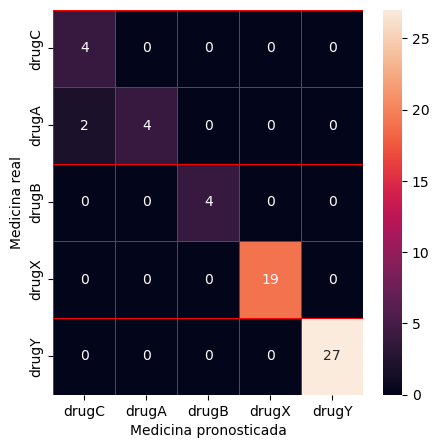

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



In [17]:
# Crear objeto de clasificación del arbol de desición
#Sección que se alterara para encontrar el mejor resultado posible
clf = DecisionTreeClassifier()


#Aplicación del algoritmo de árboles de desición a los arboles de entrenamiento
clf = clf.fit(X_train, y_train)
#Predicción de la respuesta para el grupo de prueba
y_pred = clf.predict(X_test)

# Matriz de confusión 
from sklearn.metrics import confusion_matrix
Matriz_Confusion = confusion_matrix(y_test, y_pred)

MapaCalor_Multiples(list(set(y)), Matriz_Confusion)

# Estadísticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

### Seccion Gini

Capaz maximas = 2

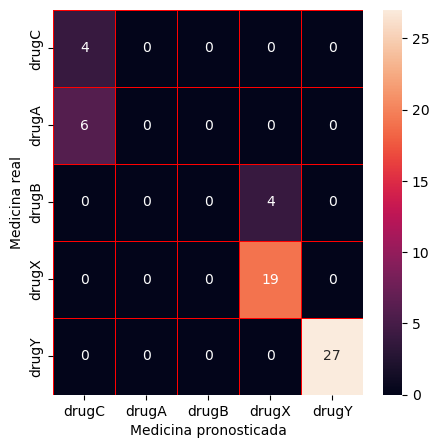

              precision    recall  f1-score   support

       drugA       0.40      1.00      0.57         4
       drugB       0.00      0.00      0.00         6
       drugC       0.00      0.00      0.00         4
       drugX       0.83      1.00      0.90        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.83        60
   macro avg       0.45      0.60      0.50        60
weighted avg       0.74      0.83      0.77        60



In [21]:
#Sección que se alterara para encontrar el mejor resultado posible
clf = DecisionTreeClassifier(criterion = "gini", max_depth = 2)


#Aplicación del algoritmo de árboles de desición a los arboles de entrenamiento
clf = clf.fit(X_train, y_train)
#Predicción de la respuesta para el grupo de prueba
y_pred = clf.predict(X_test)

# Matriz de confusión 
from sklearn.metrics import confusion_matrix
Matriz_Confusion = confusion_matrix(y_test, y_pred)

MapaCalor_Multiples(list(set(y)), Matriz_Confusion)

# Estadísticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Capaz maximas = 3

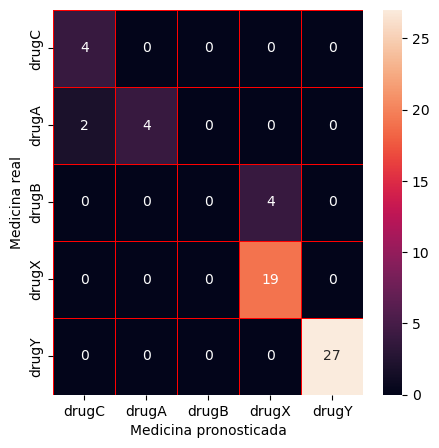

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       0.00      0.00      0.00         4
       drugX       0.83      1.00      0.90        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.90        60
   macro avg       0.70      0.73      0.70        60
weighted avg       0.86      0.90      0.87        60



In [24]:
#Sección que se alterara para encontrar el mejor resultado posible
clf = DecisionTreeClassifier(criterion = "gini", max_depth = 3)


#Aplicación del algoritmo de árboles de desición a los arboles de entrenamiento
clf = clf.fit(X_train, y_train)
#Predicción de la respuesta para el grupo de prueba
y_pred = clf.predict(X_test)

# Matriz de confusión 
from sklearn.metrics import confusion_matrix
Matriz_Confusion = confusion_matrix(y_test, y_pred)

MapaCalor_Multiples(list(set(y)), Matriz_Confusion)

# Estadísticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Capaz maximas = 4

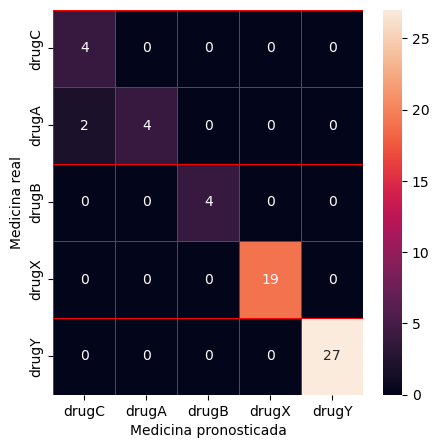

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



In [27]:
#Sección que se alterara para encontrar el mejor resultado posible
clf = DecisionTreeClassifier(criterion = "gini", max_depth = 4)


#Aplicación del algoritmo de árboles de desición a los arboles de entrenamiento
clf = clf.fit(X_train, y_train)
#Predicción de la respuesta para el grupo de prueba
y_pred = clf.predict(X_test)

# Matriz de confusión 
from sklearn.metrics import confusion_matrix
Matriz_Confusion = confusion_matrix(y_test, y_pred)

MapaCalor_Multiples(list(set(y)), Matriz_Confusion)

# Estadísticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Capaz maximas = 5

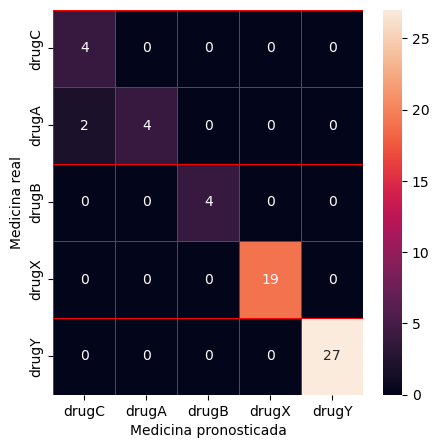

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



In [30]:
#Sección que se alterara para encontrar el mejor resultado posible
clf = DecisionTreeClassifier(criterion = "gini", max_depth = 5)


#Aplicación del algoritmo de árboles de desición a los arboles de entrenamiento
clf = clf.fit(X_train, y_train)
#Predicción de la respuesta para el grupo de prueba
y_pred = clf.predict(X_test)

# Matriz de confusión 
from sklearn.metrics import confusion_matrix
Matriz_Confusion = confusion_matrix(y_test, y_pred)

MapaCalor_Multiples(list(set(y)), Matriz_Confusion)

# Estadísticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Capaz maximas = 6

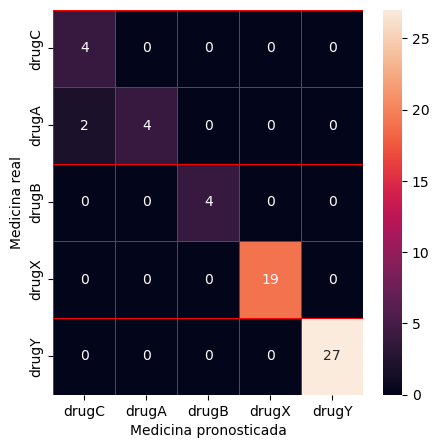

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



In [33]:
#Sección que se alterara para encontrar el mejor resultado posible
clf = DecisionTreeClassifier(criterion = "gini", max_depth = 6)


#Aplicación del algoritmo de árboles de desición a los arboles de entrenamiento
clf = clf.fit(X_train, y_train)
#Predicción de la respuesta para el grupo de prueba
y_pred = clf.predict(X_test)

# Matriz de confusión 
from sklearn.metrics import confusion_matrix
Matriz_Confusion = confusion_matrix(y_test, y_pred)

MapaCalor_Multiples(list(set(y)), Matriz_Confusion)

# Estadísticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

### Seccion Entropia

Capaz maximas = 2

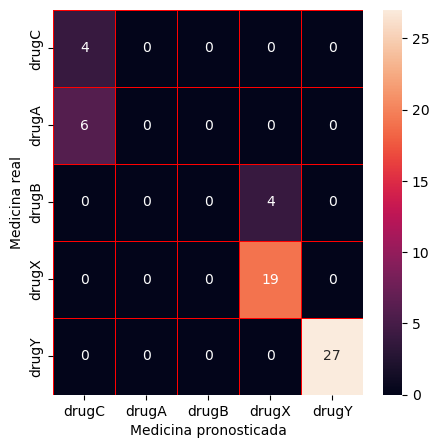

              precision    recall  f1-score   support

       drugA       0.40      1.00      0.57         4
       drugB       0.00      0.00      0.00         6
       drugC       0.00      0.00      0.00         4
       drugX       0.83      1.00      0.90        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.83        60
   macro avg       0.45      0.60      0.50        60
weighted avg       0.74      0.83      0.77        60



In [37]:
#Sección que se alterara para encontrar el mejor resultado posible
clf = DecisionTreeClassifier(criterion = "entropy", max_depth = 2)


#Aplicación del algoritmo de árboles de desición a los arboles de entrenamiento
clf = clf.fit(X_train, y_train)
#Predicción de la respuesta para el grupo de prueba
y_pred = clf.predict(X_test)

# Matriz de confusión 
from sklearn.metrics import confusion_matrix
Matriz_Confusion = confusion_matrix(y_test, y_pred)

MapaCalor_Multiples(list(set(y)), Matriz_Confusion)

# Estadísticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Capaz maximas = 3

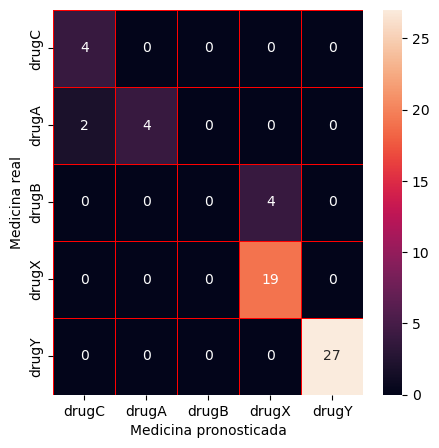

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       0.00      0.00      0.00         4
       drugX       0.83      1.00      0.90        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.90        60
   macro avg       0.70      0.73      0.70        60
weighted avg       0.86      0.90      0.87        60



In [40]:
#Sección que se alterara para encontrar el mejor resultado posible
clf = DecisionTreeClassifier(criterion = "entropy", max_depth = 3)


#Aplicación del algoritmo de árboles de desición a los arboles de entrenamiento
clf = clf.fit(X_train, y_train)
#Predicción de la respuesta para el grupo de prueba
y_pred = clf.predict(X_test)

# Matriz de confusión 
from sklearn.metrics import confusion_matrix
Matriz_Confusion = confusion_matrix(y_test, y_pred)

MapaCalor_Multiples(list(set(y)), Matriz_Confusion)

# Estadísticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Capaz maximas = 4

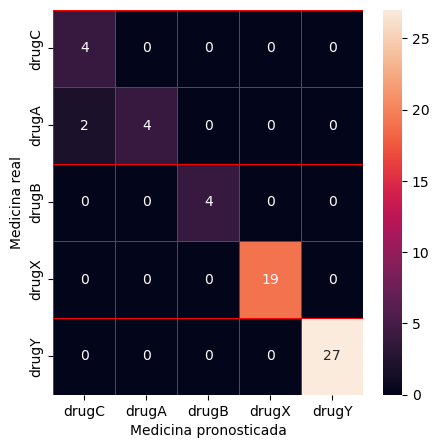

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



In [43]:
#Sección que se alterara para encontrar el mejor resultado posible
clf = DecisionTreeClassifier(criterion = "entropy", max_depth = 4)


#Aplicación del algoritmo de árboles de desición a los arboles de entrenamiento
clf = clf.fit(X_train, y_train)
#Predicción de la respuesta para el grupo de prueba
y_pred = clf.predict(X_test)

# Matriz de confusión 
from sklearn.metrics import confusion_matrix
Matriz_Confusion = confusion_matrix(y_test, y_pred)

MapaCalor_Multiples(list(set(y)), Matriz_Confusion)

# Estadísticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Capaz maximas = 5

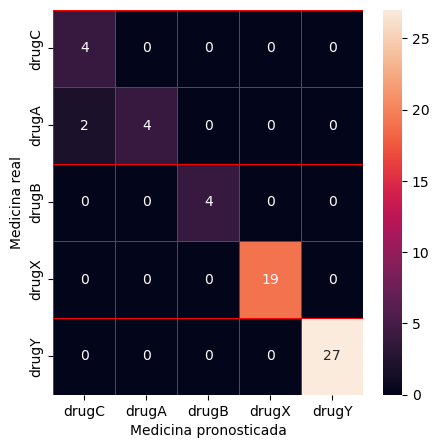

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



In [46]:
#Sección que se alterara para encontrar el mejor resultado posible
clf = DecisionTreeClassifier(criterion = "entropy", max_depth = 5)


#Aplicación del algoritmo de árboles de desición a los arboles de entrenamiento
clf = clf.fit(X_train, y_train)
#Predicción de la respuesta para el grupo de prueba
y_pred = clf.predict(X_test)

# Matriz de confusión 
from sklearn.metrics import confusion_matrix
Matriz_Confusion = confusion_matrix(y_test, y_pred)

MapaCalor_Multiples(list(set(y)), Matriz_Confusion)

# Estadísticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Capaz maximas = 6

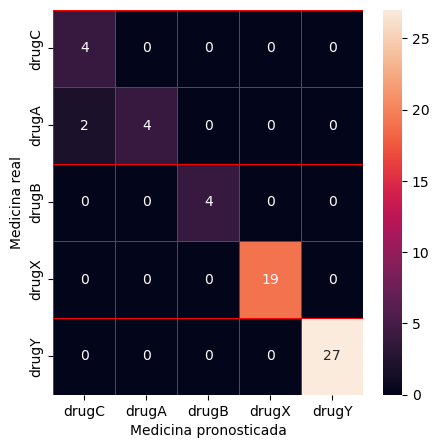

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



In [49]:
#Sección que se alterara para encontrar el mejor resultado posible
clf = DecisionTreeClassifier(criterion = "entropy", max_depth = 6)


#Aplicación del algoritmo de árboles de desición a los arboles de entrenamiento
clf = clf.fit(X_train, y_train)
#Predicción de la respuesta para el grupo de prueba
y_pred = clf.predict(X_test)

# Matriz de confusión 
from sklearn.metrics import confusion_matrix
Matriz_Confusion = confusion_matrix(y_test, y_pred)

MapaCalor_Multiples(list(set(y)), Matriz_Confusion)

# Estadísticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

### Analisis

Dado a lo relativamente simple de ambos procesos no hubo muchos cambios entre ambas graficas o modelos, pero debido a los "simple" del modelo este presenta comportamiento similar a partir de la cuarta capa máxima de decisión, y esto se mantiene igual tanto en Gini como en entropía, aunque para este caso se seleccionaría Gini debido a que tiene menor tiempo de procesamiento lo cual también seria útil en la práctica.
Presenta una precisión del 97% además de que de todas las predicciones únicamente tuvo error en 2 de ellas por lo cual el modelo es decente.

Entonces los parámetros mas óptimos según mi análisis serian (con solo los parámetros analizados):
1. Capa Maxima = 4
2. Criterion = Gini

## Extras (Localizando la mejor opcion con una funcion)

In [54]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(1, 10, 1),
    # min_samples_leaf': range(1, 20, 2),
    #'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
}

Arbol = DecisionTreeClassifier(random_state=1)

Grid_Search = GridSearchCV(estimator=Arbol, param_grid=param_grid, 
                           cv=5, verbose=True)
Grid_Search.fit(X_train, y_train)

print("Mejor precision", Grid_Search.best_score_)
print(Grid_Search.best_estimator_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejor precision 0.9928571428571429
DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=1)


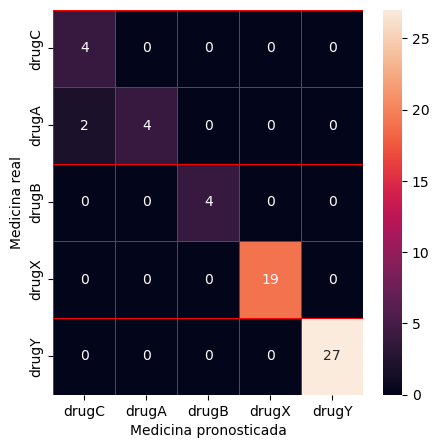

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



In [56]:
#Sección que se alterara para encontrar el mejor resultado posible
clf = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=1)


#Aplicación del algoritmo de árboles de desición a los arboles de entrenamiento
clf = clf.fit(X_train, y_train)
#Predicción de la respuesta para el grupo de prueba
y_pred = clf.predict(X_test)

# Matriz de confusión 
from sklearn.metrics import confusion_matrix
Matriz_Confusion = confusion_matrix(y_test, y_pred)

MapaCalor_Multiples(list(set(y)), Matriz_Confusion)

# Estadísticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Lo más probable en este caso es que se seleccionó entropía dado que presenta dos características principales:
1. Tiene menor sensibilidad que el de GINI
2. Tiene una mayor sensibilidad al NUMERO DE CLASES
3. Tiene una inclinación a seleccionar sesgos que GENEREN UNA MENOR INCERTIDUMBRE

In [59]:
from sklearn import tree
import graphviz
import pydotplus
from PIL import Image

# Creación de información para el árbol (reglas de desición)
dot_data = tree.export_graphviz(clf, out_file = None, feature_names = feature_cols, class_names=list(set(y)))

#Creación de la gráfica del árbol
graph = pydotplus.graph_from_dot_data(dot_data)

# Creación del árbol en formato PNG
graph.write_png("M23-Medicina.png")

image = Image.open("M23-Medicina.png")
image.show()

### ¿Qué medicamento recomendaría utilizar para un paciente con los siguientes datos? 

* Age = 50
* Sex = F
* BP = High
* Cholesterol = Normal
* Na_to_K = 15.302

In [63]:
ejemplo = X_test[0,:]
ejemplo[0] = 50 #Age
ejemplo[1] = 1 # 0 = Male , 1= Female 
ejemplo[2] = 2 # 0= Normal, 1=LOW, 2=High
ejemplo[3] = 0 # 0= Normal, 1=High
ejemplo[4] = 15.302
Prediccion_ValorPrueba = np.array([ejemplo]) # El codigo requeria una matriz de 2 dimensiones para funcionar pero al copiar solo una ilera la
                                             # volvia una matriz de una dimension.

In [65]:
print("La prediccion es la medicina: ", clf.predict(Prediccion_ValorPrueba))

La prediccion es la medicina:  ['drugY']
